# HF TDOA vs Ionosonde Scatter Plot Comparison - Figure 14

This notebook creates scatter plots comparing HF TDOA height measurements with Austin Ionosonde hmF2 values.

The analysis includes:
- Manual TDOA measurements (period and autocorrelation analysis)
- Automated TDOA measurements from Figures 11-13
- Austin Ionosonde hmF2 reference data

Outputs:
- Individual scatter plots for each dataset vs ionosonde
- Combined scatter plot with all datasets
- Resampling validation plots to verify data fidelity

In [1]:
import os
import pandas as pd
import hf_tdoa as tdoa

%matplotlib inline

# Setup plotting style
tdoa.setup_plotting_style()

## Load Austin Ionosonde Data

Load the manually-scaled Austin TX ionosonde data to use as reference values for hmF2.

In [2]:
# Load ionosonde data
ionosonde_csv = '../data/CSVs/2024-04-08_AU930_AustinTX_Ionosonde_ManualScaled.csv'
ionosonde_df = tdoa.load_ionosonde_data(ionosonde_csv)

print(f"Ionosonde data loaded: {len(ionosonde_df)} records")
print(f"Time range: {ionosonde_df.index[0]} to {ionosonde_df.index[-1]}")
print(f"\nFirst few records:")
print(ionosonde_df[['hmF2']].head())

Ionosonde data loaded: 288 records
Time range: 2024-04-08 00:00:05 to 2024-04-08 23:55:05

First few records:
                      hmF2
UTC                       
2024-04-08 00:00:05  286.5
2024-04-08 00:05:05  296.1
2024-04-08 00:10:05  282.9
2024-04-08 00:15:05  286.6
2024-04-08 00:20:05  286.7


## Load Manual and Automated TDOA Datasets

Load TDOA measurements from both manual and automated analysis:

### Manual Analysis (Period and Autocorrelation):
1. N5DUP 40m - Manual Period Analysis
2. N5DUP 40m - Manual Autocorrelation Analysis
3. AB5YO 40m - Manual Period Analysis
4. AB5YO 40m - Manual Autocorrelation Analysis
5. AB5YO 60m - Manual Period Analysis
6. AB5YO 60m - Manual Autocorrelation Analysis

### Automated Analysis (Figures 11-13):
1. N5DUP 40m (2F2-1F2) - Figure 11
2. AB5YO 40m (2F2-1F2) - Figure 12
3. AB5YO 60m (2F2-1F2) - Figure 12
4. N6RFM 40m (2F2-1F2) - Figure 13
5. N6RFM 40m (1F2-1E) - Figure 13
6. N6RFM 40m (2F2-1E) - Figure 13

In [3]:
# Define manual and automated TDOA datasets separately
# Using distinct colors and markers for each dataset

manual_datasets = []
automated_datasets = []

# ========================================================================
# Manual TDOA Datasets (using load_tdoa_csv_generic)
# Marker convention: '^' for Manual Period, 'v' for Manual Autocorr
# Color scheme: N5DUP=blue, AB5YO 40m=orange, AB5YO 60m=green
# ========================================================================

# N5DUP 40m - Manual Period Analysis
manual_n5dup_period = tdoa.load_tdoa_csv_generic(
    '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-40m_manual_period_analysis.csv'
)
manual_datasets.append({
    'df': manual_n5dup_period,
    'label': 'N5DUP 40m (Manual Period)',
    'color': '#1f77b4',  # blue
    'marker': '^'  # Manual Period
})

# N5DUP 40m - Manual Autocorrelation Analysis
manual_n5dup_auto = tdoa.load_tdoa_csv_generic(
    '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-40m_manual_autocorrelation_analysis.csv'
)
manual_datasets.append({
    'df': manual_n5dup_auto,
    'label': 'N5DUP 40m (Manual Autocorr)',
    'color': '#1f77b4',  # blue
    'marker': 'v'  # Manual Autocorr
})

# AB5YO 40m - Manual Period Analysis
manual_ab5yo_40m_period = tdoa.load_tdoa_csv_generic(
    '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-40m_manual_period_analysis.csv'
)
manual_datasets.append({
    'df': manual_ab5yo_40m_period,
    'label': 'AB5YO 40m (Manual Period)',
    'color': '#ff7f0e',  # orange
    'marker': '^'  # Manual Period
})

# AB5YO 40m - Manual Autocorrelation Analysis
manual_ab5yo_40m_auto = tdoa.load_tdoa_csv_generic(
    '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-40m_manual_autocorrelation_analysis.csv'
)
manual_datasets.append({
    'df': manual_ab5yo_40m_auto,
    'label': 'AB5YO 40m (Manual Autocorr)',
    'color': '#ff7f0e',  # orange
    'marker': 'v'  # Manual Autocorr
})

# AB5YO 60m - Manual Period Analysis
manual_ab5yo_60m_period = tdoa.load_tdoa_csv_generic(
    '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-60m_manual_period_analysis.csv'
)
manual_datasets.append({
    'df': manual_ab5yo_60m_period,
    'label': 'AB5YO 60m (Manual Period)',
    'color': '#2ca02c',  # green
    'marker': '^'  # Manual Period
})

# AB5YO 60m - Manual Autocorrelation Analysis
manual_ab5yo_60m_auto = tdoa.load_tdoa_csv_generic(
    '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-60m_manual_autocorrelation_analysis.csv'
)
manual_datasets.append({
    'df': manual_ab5yo_60m_auto,
    'label': 'AB5YO 60m (Manual Autocorr)',
    'color': '#2ca02c',  # green
    'marker': 'v'  # Manual Autocorr
})

# ========================================================================
# Automated TDOA Datasets (using TDOAData class)
# Marker convention: 'o' for 2F2-1F2, 'x' for 1F2-1E, '+' for 2F2-1E
# N6RFM datasets: 'o' uses 0.2 gray, 'x' and '+' use black with thicker lines
# Zorder: N5DUP (top=4), AB5YO 40m (3), AB5YO 60m (2), N6RFM (bottom=1)
# ========================================================================

# N5DUP 40m - Automated (2F2-1F2)
auto_n5dup = tdoa.TDOAData(
    '../fig_11/output/tdoa_calculations/20240408_2F2-1F2_TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-40m.csv'
)
automated_datasets.append({
    'df': auto_n5dup.df[['mean_tdoa_hgt_km']].rename(columns={'mean_tdoa_hgt_km': 'height_km'}),
    'label': 'N5DUP 40m (2F2-1F2)',
    'color': '#1f77b4',  # blue
    'marker': 'o',  # 2F2-1F2 mode
    'zorder': 4  # Top layer
})

# AB5YO 40m - Automated (2F2-1F2)
auto_ab5yo_40m = tdoa.TDOAData(
    '../fig_12/output/tdoa_calculations/20240408_2F2-1F2_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-40m.csv'
)
automated_datasets.append({
    'df': auto_ab5yo_40m.df[['mean_tdoa_hgt_km']].rename(columns={'mean_tdoa_hgt_km': 'height_km'}),
    'label': 'AB5YO 40m (2F2-1F2)',
    'color': '#ff7f0e',  # orange
    'marker': 'o',  # 2F2-1F2 mode
    'zorder': 3  # Second layer
})

# AB5YO 60m - Automated (2F2-1F2)
auto_ab5yo_60m = tdoa.TDOAData(
    '../fig_12/output/tdoa_calculations/20240408_2F2-1F2_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-60m.csv'
)
automated_datasets.append({
    'df': auto_ab5yo_60m.df[['mean_tdoa_hgt_km']].rename(columns={'mean_tdoa_hgt_km': 'height_km'}),
    'label': 'AB5YO 60m (2F2-1F2)',
    'color': '#2ca02c',  # green
    'marker': 'o',  # 2F2-1F2 mode
    'zorder': 2  # Third layer
})

# N6RFM 40m - Automated (2F2-1F2)
auto_n6rfm_2f2_1f2 = tdoa.TDOAData(
    '../fig_13/output/tdoa_calculations/20240408_2F2-1F2_TX_WA5FRF_EL09nn-RX_N6RFM_EM12jw-40m.csv'
)
automated_datasets.append({
    'df': auto_n6rfm_2f2_1f2.df[['mean_tdoa_hgt_km']].rename(columns={'mean_tdoa_hgt_km': 'height_km'}),
    'label': 'N6RFM 40m (2F2-1F2)',
    'color': '0.2',  # 20% gray (dark gray)
    'edgecolor': '0.2',  # 20% gray (dark gray)
    'marker': 'o',  # 2F2-1F2 mode
    'zorder': 1  # Bottom layer
})

# N6RFM 40m - Automated (1F2-1E)
auto_n6rfm_1f2_1e = tdoa.TDOAData(
    '../fig_13/output/tdoa_calculations/20240408_1F2-1E_TX_WA5FRF_EL09nn-RX_N6RFM_EM12jw-40m.csv'
)
automated_datasets.append({
    'df': auto_n6rfm_1f2_1e.df[['mean_tdoa_hgt_km']].rename(columns={'mean_tdoa_hgt_km': 'height_km'}),
    'label': 'N6RFM 40m (1F2-1E)',
    'color': 'black',  # black
    'edgecolor': 'black',  # black
    'marker': 'x',  # 1F2-1E mode
    'linewidths': 2.0,  # Thicker lines for 'x' marker
    'zorder': 1  # Bottom layer
})

# N6RFM 40m - Automated (2F2-1E)
auto_n6rfm_2f2_1e = tdoa.TDOAData(
    '../fig_13/output/tdoa_calculations/20240408_2F2-1E_TX_WA5FRF_EL09nn-RX_N6RFM_EM12jw-40m.csv'
)
automated_datasets.append({
    'df': auto_n6rfm_2f2_1e.df[['mean_tdoa_hgt_km']].rename(columns={'mean_tdoa_hgt_km': 'height_km'}),
    'label': 'N6RFM 40m (2F2-1E)',
    'color': 'black',  # black
    'edgecolor': 'black',  # black
    'marker': '+',  # 2F2-1E mode
    'linewidths': 2.0,  # Thicker lines for '+' marker
    'zorder': 1  # Bottom layer
})

print(f"\nLoaded {len(manual_datasets)} manual TDOA datasets:")
for i, ds in enumerate(manual_datasets, 1):
    print(f"{i:2d}. {ds['label']:35s} - {len(ds['df'])} points")

print(f"\nLoaded {len(automated_datasets)} automated TDOA datasets:")
for i, ds in enumerate(automated_datasets, 1):
    print(f"{i:2d}. {ds['label']:35s} - {len(ds['df'])} points - marker: {ds['marker']}")


Loaded 6 manual TDOA datasets:
 1. N5DUP 40m (Manual Period)           - 47 points
 2. N5DUP 40m (Manual Autocorr)         - 25 points
 3. AB5YO 40m (Manual Period)           - 47 points
 4. AB5YO 40m (Manual Autocorr)         - 35 points
 5. AB5YO 60m (Manual Period)           - 39 points
 6. AB5YO 60m (Manual Autocorr)         - 38 points

Loaded 6 automated TDOA datasets:
 1. N5DUP 40m (2F2-1F2)                 - 32 points - marker: o
 2. AB5YO 40m (2F2-1F2)                 - 49 points - marker: o
 3. AB5YO 60m (2F2-1F2)                 - 39 points - marker: o
 4. N6RFM 40m (2F2-1F2)                 - 39 points - marker: o
 5. N6RFM 40m (1F2-1E)                  - 39 points - marker: x
 6. N6RFM 40m (2F2-1E)                  - 39 points - marker: +


## Resampling Validation

Before comparing with ionosonde data, we need to resample TDOA measurements to match the 5-minute ionosonde cadence.

This section shows validation plots demonstrating that resampling faithfully represents the original data.
We plot:
- Original TDOA data points (scatter)
- Resampled 5-minute data (line with markers)

This allows visual verification that no important features are lost during resampling.

In [4]:
import matplotlib.pyplot as plt

# Create resampling validation plots for each dataset
output_dir = 'output'
os.makedirs(output_dir, exist_ok=True)

print("Creating resampling validation plots...\n")

print("Manual datasets:")
for dataset in manual_datasets:
    # Resample data
    aligned_df, resampled_df = tdoa.align_and_resample_data(
        dataset['df'], ionosonde_df, resample_rule='5min', method='linear'
    )
    
    # Create validation plot
    fig, ax = plt.subplots(figsize=(14, 5))
    tdoa.plot_resampling_validation(
        dataset['df'],
        resampled_df,
        label=dataset['label'],
        color=dataset['color'],
        ax=ax,
        savefig=os.path.join(output_dir, f"resample_validation_{dataset['label'].replace(' ', '_').replace('/', '-')}.jpg")
    )
    plt.close()

print("\nAutomated datasets:")
for dataset in automated_datasets:
    # Resample data
    aligned_df, resampled_df = tdoa.align_and_resample_data(
        dataset['df'], ionosonde_df, resample_rule='5min', method='linear'
    )
    
    # Create validation plot
    fig, ax = plt.subplots(figsize=(14, 5))
    tdoa.plot_resampling_validation(
        dataset['df'],
        resampled_df,
        label=dataset['label'],
        color=dataset['color'],
        ax=ax,
        savefig=os.path.join(output_dir, f"resample_validation_{dataset['label'].replace(' ', '_').replace('/', '-')}.jpg")
    )
    plt.close()
    
print("\nResampling validation plots saved to output/ directory")

Creating resampling validation plots...

Manual datasets:
Resampling validation plot saved to: output/resample_validation_N5DUP_40m_(Manual_Period).jpg
Resampling validation plot saved to: output/resample_validation_N5DUP_40m_(Manual_Autocorr).jpg
Resampling validation plot saved to: output/resample_validation_AB5YO_40m_(Manual_Period).jpg
Resampling validation plot saved to: output/resample_validation_AB5YO_40m_(Manual_Autocorr).jpg
Resampling validation plot saved to: output/resample_validation_AB5YO_60m_(Manual_Period).jpg
Resampling validation plot saved to: output/resample_validation_AB5YO_60m_(Manual_Autocorr).jpg

Automated datasets:
Resampling validation plot saved to: output/resample_validation_N5DUP_40m_(2F2-1F2).jpg
Resampling validation plot saved to: output/resample_validation_AB5YO_40m_(2F2-1F2).jpg
Resampling validation plot saved to: output/resample_validation_AB5YO_60m_(2F2-1F2).jpg
Resampling validation plot saved to: output/resample_validation_N6RFM_40m_(2F2-1F2).jpg

In [5]:
# Debug: Check data alignment for first manual and automated dataset
print("Debugging data alignment...\n")

# Check the first manual dataset
print("=" * 80)
print("MANUAL DATASET")
print("=" * 80)
test_dataset = manual_datasets[0]
print(f"Dataset: {test_dataset['label']}")
print(f"TDOA DataFrame shape: {test_dataset['df'].shape}")
print(f"TDOA DataFrame columns: {test_dataset['df'].columns.tolist()}")
print(f"TDOA DataFrame index range: {test_dataset['df'].index.min()} to {test_dataset['df'].index.max()}")
print(f"\nFirst few TDOA values:")
print(test_dataset['df'].head())

print(f"\n\nIonosonde DataFrame shape: {ionosonde_df.shape}")
print(f"Ionosonde index range: {ionosonde_df.index.min()} to {ionosonde_df.index.max()}")
print(f"\nFirst few Ionosonde hmF2 values:")
print(ionosonde_df[['hmF2']].head())

# Try alignment
aligned_df, resampled_df = tdoa.align_and_resample_data(test_dataset['df'], ionosonde_df)
print(f"\n\nAligned DataFrame shape: {aligned_df.shape}")
print(f"Aligned DataFrame columns: {aligned_df.columns.tolist()}")
if len(aligned_df) > 0:
    print(f"\nFirst few aligned values:")
    print(aligned_df.head(10))
    print(f"\nAligned data statistics:")
    print(aligned_df.describe())
else:
    print("\nWARNING: No aligned data! Check timestamp overlap.")

# Check the first automated dataset
print("\n\n" + "=" * 80)
print("AUTOMATED DATASET")
print("=" * 80)
test_dataset = automated_datasets[0]
print(f"Dataset: {test_dataset['label']}")
print(f"TDOA DataFrame shape: {test_dataset['df'].shape}")
print(f"TDOA DataFrame columns: {test_dataset['df'].columns.tolist()}")
print(f"TDOA DataFrame index range: {test_dataset['df'].index.min()} to {test_dataset['df'].index.max()}")
print(f"\nFirst few TDOA values:")
print(test_dataset['df'].head())

# Try alignment
aligned_df, resampled_df = tdoa.align_and_resample_data(test_dataset['df'], ionosonde_df)
print(f"\n\nAligned DataFrame shape: {aligned_df.shape}")
print(f"Aligned DataFrame columns: {aligned_df.columns.tolist()}")
if len(aligned_df) > 0:
    print(f"\nFirst few aligned values:")
    print(aligned_df.head(10))
    print(f"\nAligned data statistics:")
    print(aligned_df.describe())
else:
    print("\nWARNING: No aligned data! Check timestamp overlap.")

Debugging data alignment...

MANUAL DATASET
Dataset: N5DUP 40m (Manual Period)
TDOA DataFrame shape: (47, 1)
TDOA DataFrame columns: ['height_km']
TDOA DataFrame index range: 2024-04-08 14:13:00 to 2024-04-08 20:13:00

First few TDOA values:
                     height_km
utc                           
2024-04-08 14:13:00     266.14
2024-04-08 14:23:00     261.88
2024-04-08 14:33:00     280.34
2024-04-08 14:43:00     303.06
2024-04-08 14:54:00     304.48


Ionosonde DataFrame shape: (288, 6)
Ionosonde index range: 2024-04-08 00:00:05 to 2024-04-08 23:55:05

First few Ionosonde hmF2 values:
                      hmF2
UTC                       
2024-04-08 00:00:05  286.5
2024-04-08 00:05:05  296.1
2024-04-08 00:10:05  282.9
2024-04-08 00:15:05  286.6
2024-04-08 00:20:05  286.7


Aligned DataFrame shape: (33, 2)
Aligned DataFrame columns: ['tdoa_height', 'hmF2']

First few aligned values:
                     tdoa_height    hmF2
utc                                     
2024-04-08 14:13:00

## Individual Scatter Plots

Create individual scatter plots for each TDOA dataset vs Austin Ionosonde hmF2.

Each plot includes:
- Scatter points (TDOA height vs Ionosonde hmF2)
- Statistics box showing correlation and error metrics

### Statistical Metrics

The following statistical metrics are calculated to quantify the agreement between TDOA-derived heights and ionosonde hmF2 measurements:

**Correlation Coefficient (r)**
- Measures the linear relationship between TDOA and ionosonde heights
- Calculated as: $r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$
- Where $x_i$ are ionosonde values, $y_i$ are TDOA values
- Range: -1 to +1 (perfect correlation at ±1, no correlation at 0)
- Values close to +1 indicate strong positive linear relationship

**Root Mean Square Error (RMSE)**
- Measures the average magnitude of errors between TDOA and ionosonde heights
- Calculated as: $\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - x_i)^2}$
- Where $y_i$ are TDOA heights, $x_i$ are ionosonde heights (reference), $n$ is number of points
- Units: kilometers (km)
- Lower values indicate better agreement
- Sensitive to large errors (outliers)

**Bias**
- Measures the systematic offset between TDOA and ionosonde heights
- Calculated as: $\text{Bias} = \frac{1}{n}\sum_{i=1}^{n} (y_i - x_i) = \bar{y} - \bar{x}$
- Where $y_i$ are TDOA heights, $x_i$ are ionosonde heights (reference)
- Units: kilometers (km)
- Positive bias: TDOA systematically overestimates height
- Negative bias: TDOA systematically underestimates height
- Zero bias: no systematic offset (but may still have random errors)

**Percent Error**
- Expresses RMSE and Bias as percentages relative to the ionosonde reference values
- Calculated as:
  - $\text{RMSE}(\%) = \frac{\text{RMSE}}{\bar{x}} \times 100$
  - $\text{Bias}(\%) = \frac{\text{Bias}}{\bar{x}} \times 100$
- Where $\bar{x}$ is the mean of ionosonde heights (reference values)
- Allows comparison of errors across different measurement scales
- Lower absolute values indicate better agreement

Creating individual scatter plots...

Manual Analysis:
Saved: output/scatter_N5DUP_40m_(Manual_Period).jpg
Saved: output/scatter_N5DUP_40m_(Manual_Autocorr).jpg
Saved: output/scatter_AB5YO_40m_(Manual_Period).jpg
Saved: output/scatter_AB5YO_40m_(Manual_Autocorr).jpg
Saved: output/scatter_AB5YO_60m_(Manual_Period).jpg
Saved: output/scatter_AB5YO_60m_(Manual_Autocorr).jpg

Automated Analysis:
Saved: output/scatter_N5DUP_40m_(2F2-1F2).jpg
Saved: output/scatter_AB5YO_40m_(2F2-1F2).jpg
Saved: output/scatter_AB5YO_60m_(2F2-1F2).jpg
Saved: output/scatter_N6RFM_40m_(2F2-1F2).jpg
Saved: output/scatter_N6RFM_40m_(1F2-1E).jpg


/Users/r01344106/code/frontiers/HF-TDOA-Frontiers-2025/hf_tdoa/hf_tdoa_lib.py:2657: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(ionosonde_hmf2, tdoa_height, **scatter_kwargs)
/Users/r01344106/code/frontiers/HF-TDOA-Frontiers-2025/hf_tdoa/hf_tdoa_lib.py:2657: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(ionosonde_hmf2, tdoa_height, **scatter_kwargs)


Saved: output/scatter_N6RFM_40m_(2F2-1E).jpg

MANUAL ANALYSIS SCATTER PLOT STATISTICS
Dataset                                  n        r       RMSE       Bias
--------------------------------------------------------------------------------
N5DUP 40m (Manual Period)               33    0.465      20.8 km      12.9 km
N5DUP 40m (Manual Autocorr)             25    0.398      27.0 km      15.2 km
AB5YO 40m (Manual Period)               47    0.462      15.0 km       2.3 km
AB5YO 40m (Manual Autocorr)             35    0.373      17.6 km      -3.7 km
AB5YO 60m (Manual Period)               39    0.679      26.9 km     -21.9 km
AB5YO 60m (Manual Autocorr)             38    0.531      27.3 km     -18.7 km

AUTOMATED ANALYSIS SCATTER PLOT STATISTICS
Dataset                                  n        r       RMSE       Bias
--------------------------------------------------------------------------------
N5DUP 40m (2F2-1F2)                     31    0.547      14.2 km       4.0 km
AB5YO 40m (2F2

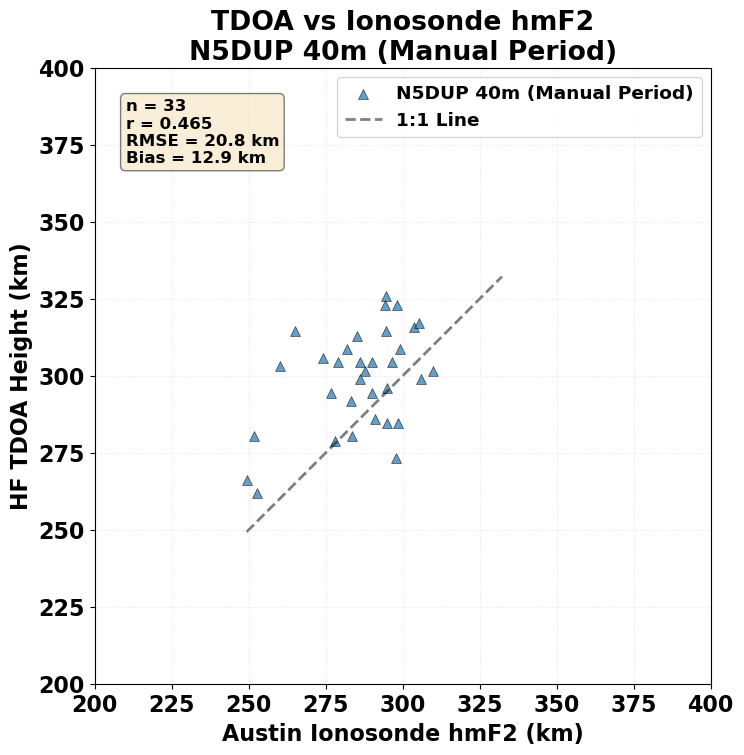

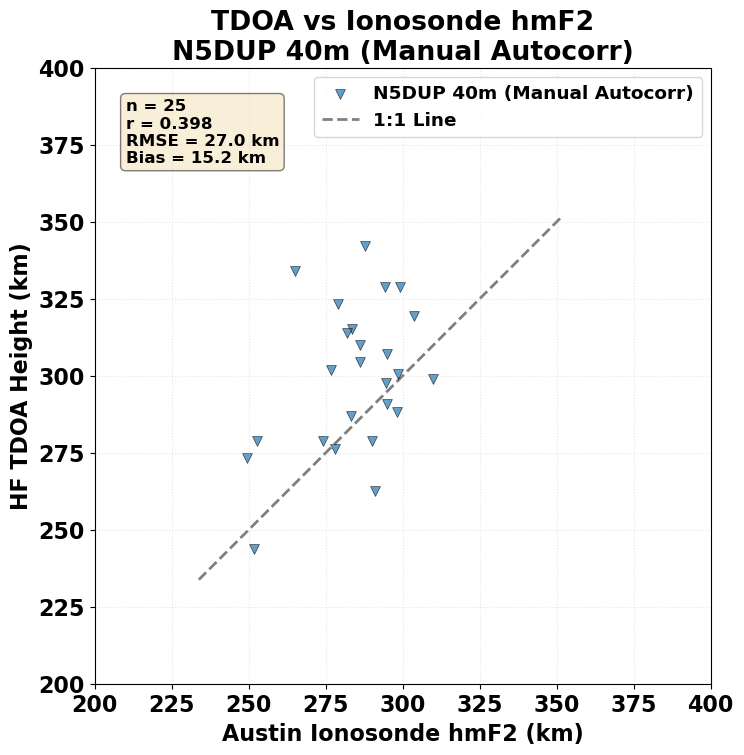

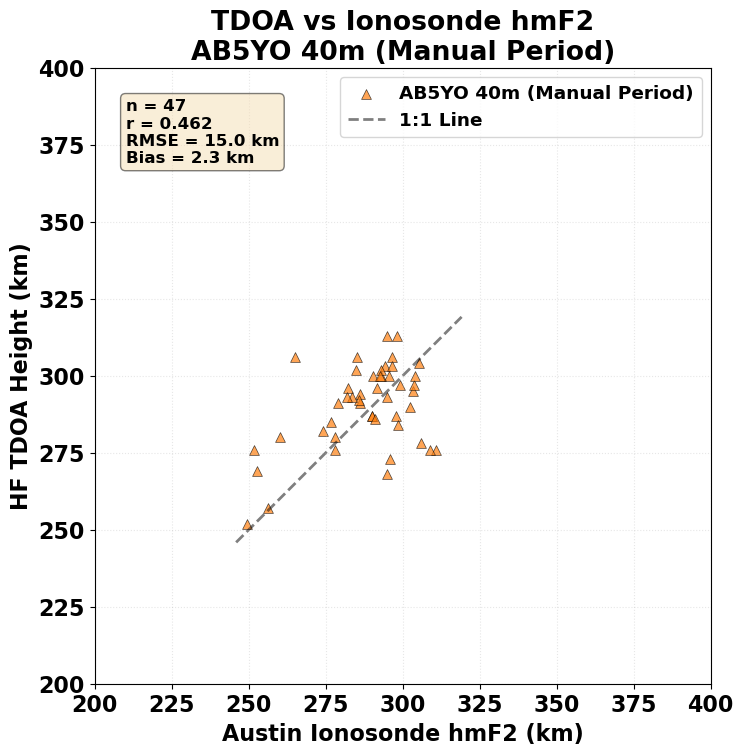

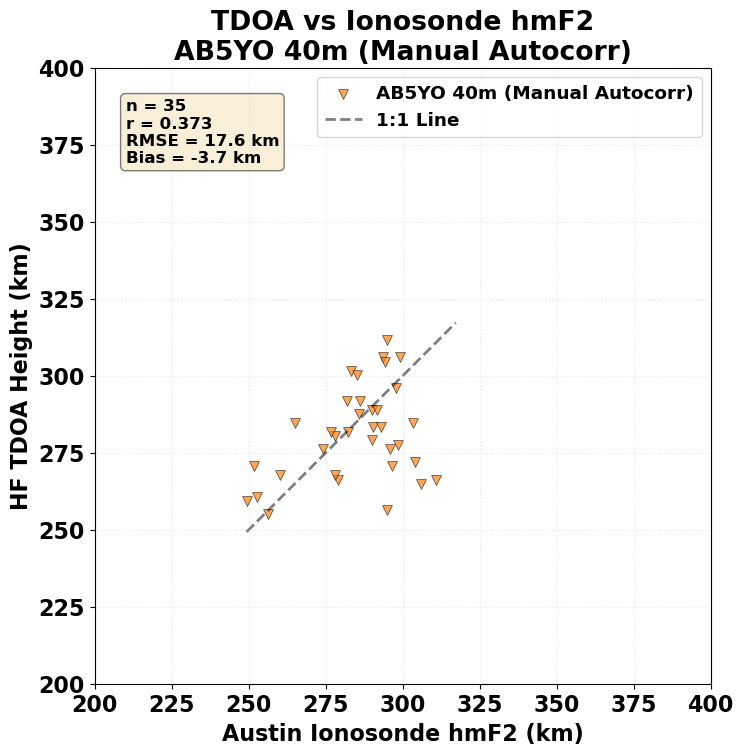

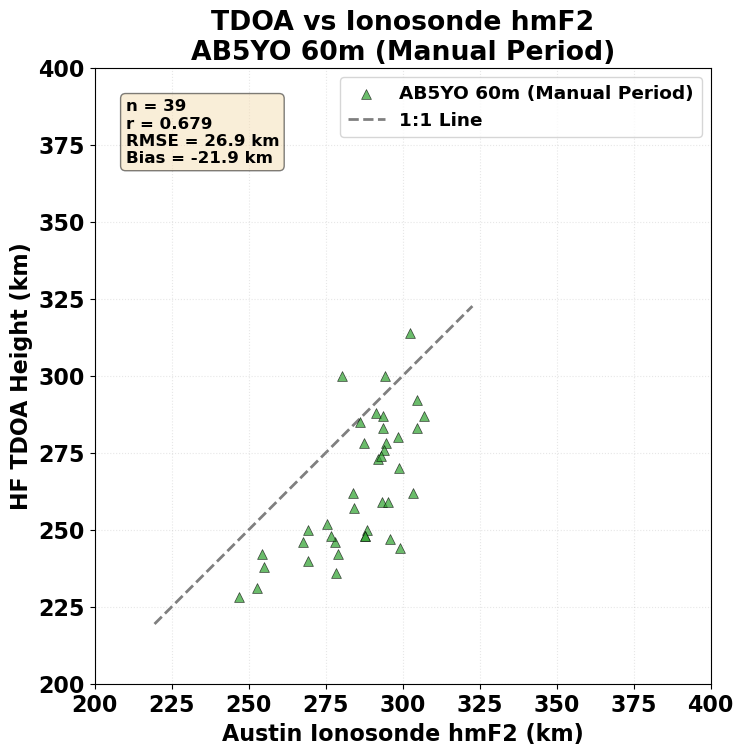

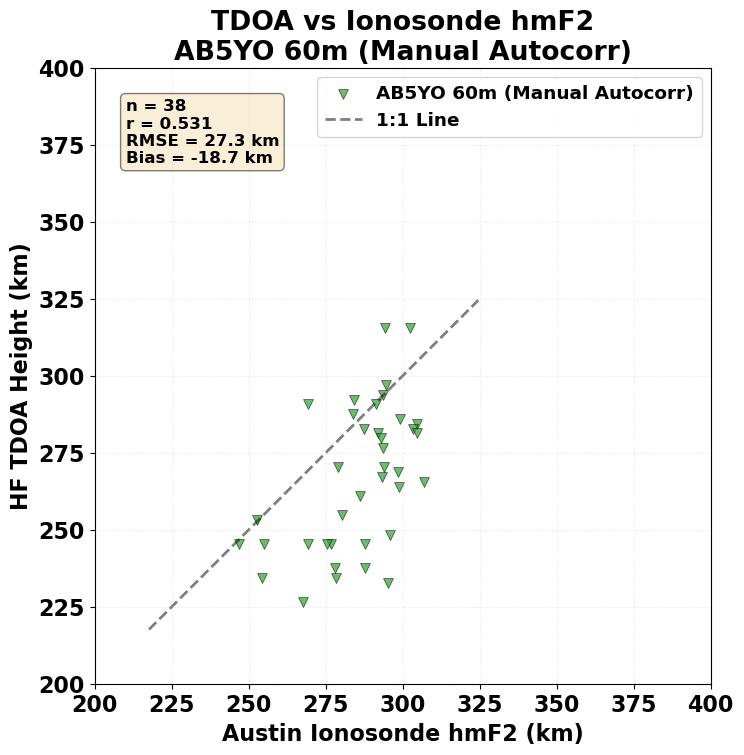

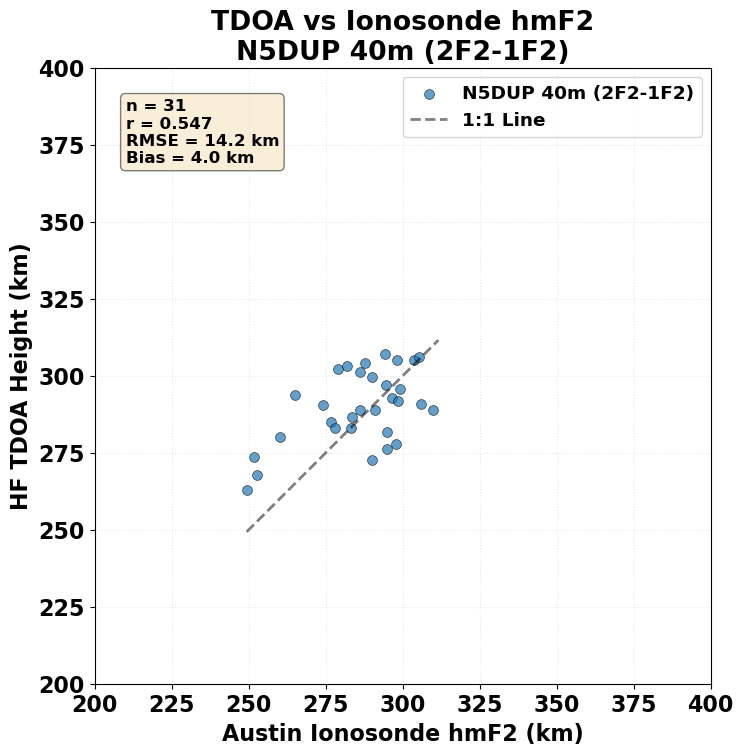

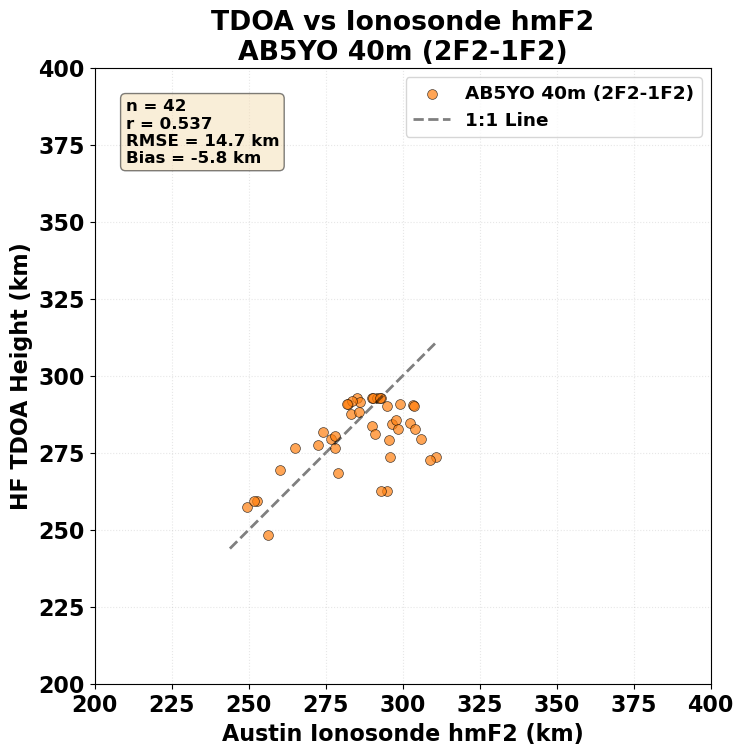

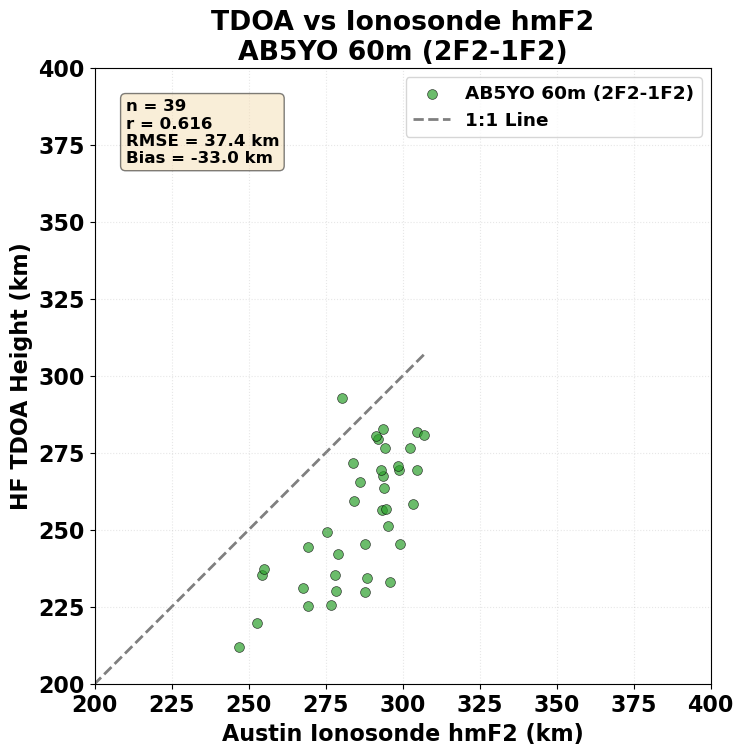

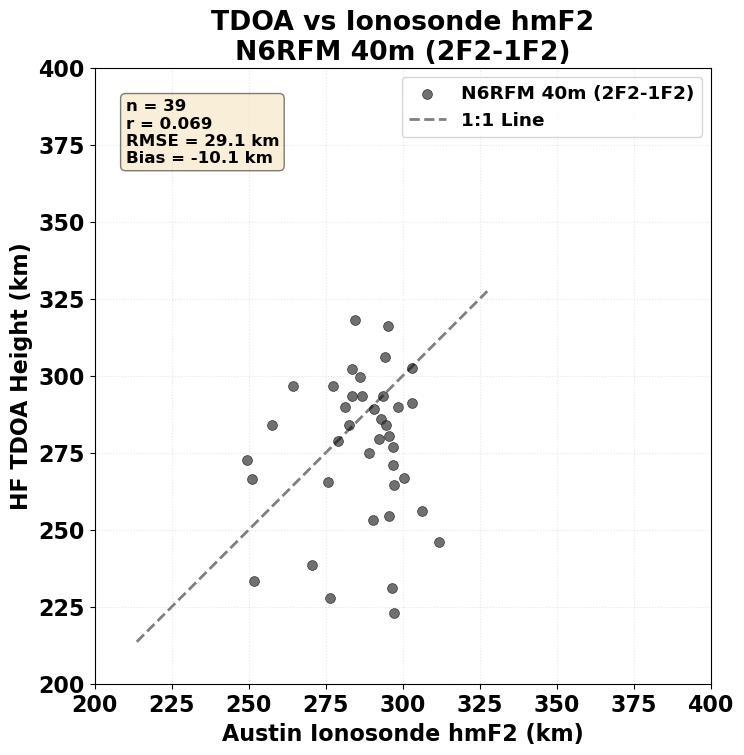

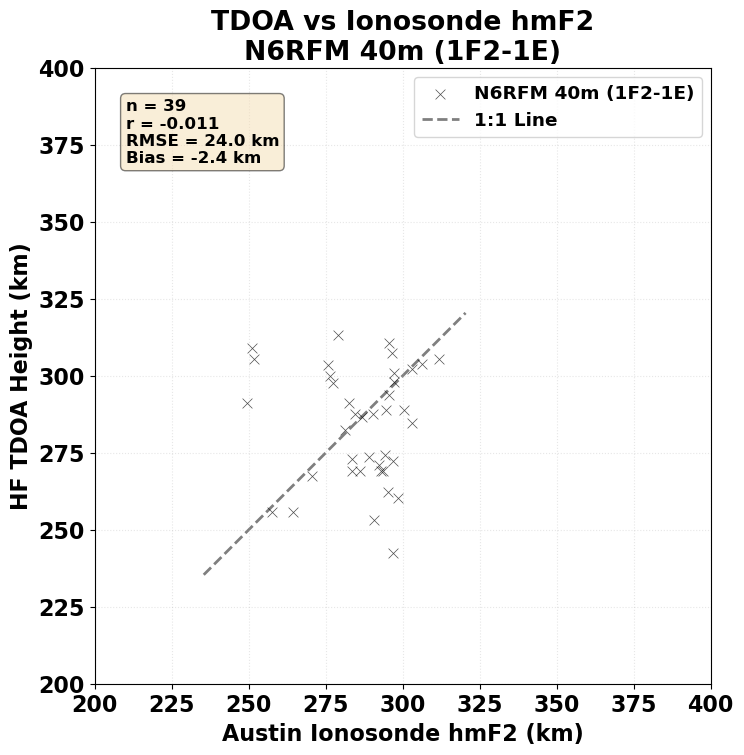

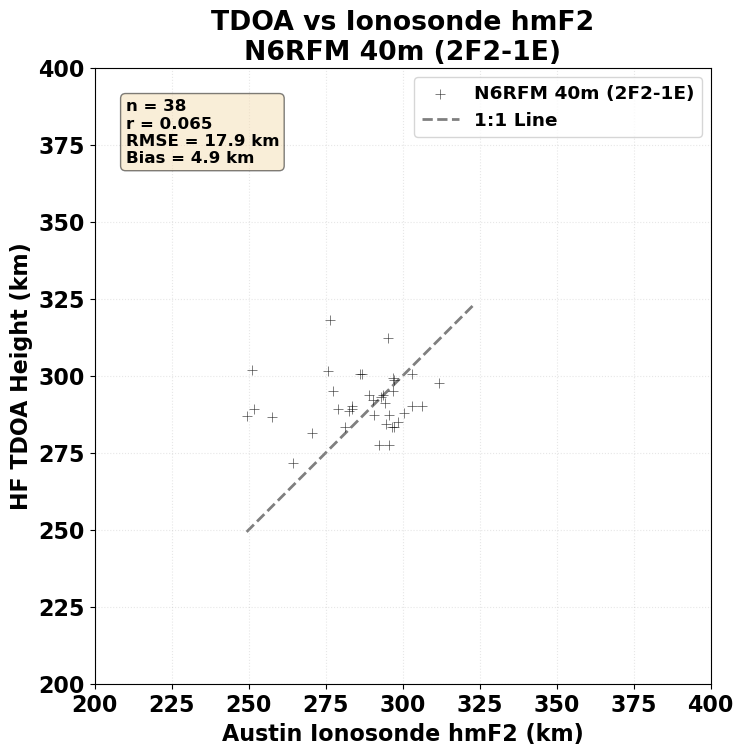

In [6]:
# Create individual scatter plots and save results
print("Creating individual scatter plots...\n")

# Manual datasets
print("Manual Analysis:")
manual_results = tdoa.create_scatter_plot_figure(
    manual_datasets,
    ionosonde_df,
    individual_plots=True,
    combined_plot=False,
    output_dir=output_dir
)

# Automated datasets
print("\nAutomated Analysis:")
automated_results = tdoa.create_scatter_plot_figure(
    automated_datasets,
    ionosonde_df,
    individual_plots=True,
    combined_plot=False,
    output_dir=output_dir
)

# Print summary statistics for manual analysis
print("\n" + "="*80)
print("MANUAL ANALYSIS SCATTER PLOT STATISTICS")
print("="*80)
print(f"{'Dataset':<35s} {'n':>6s} {'r':>8s} {'RMSE':>10s} {'Bias':>10s}")
print("-"*80)

for label, stats in manual_results.items():
    if stats:
        print(f"{label:<35s} {stats['n_points']:6d} {stats['correlation']:8.3f} "
              f"{stats['rmse']:9.1f} km {stats['bias']:9.1f} km")
    else:
        print(f"{label:<35s} {'N/A':>6s} {'N/A':>8s} {'N/A':>10s} {'N/A':>10s}")

# Print summary statistics for automated analysis
print("\n" + "="*80)
print("AUTOMATED ANALYSIS SCATTER PLOT STATISTICS")
print("="*80)
print(f"{'Dataset':<35s} {'n':>6s} {'r':>8s} {'RMSE':>10s} {'Bias':>10s}")
print("-"*80)

for label, stats in automated_results.items():
    if stats:
        print(f"{label:<35s} {stats['n_points']:6d} {stats['correlation']:8.3f} "
              f"{stats['rmse']:9.1f} km {stats['bias']:9.1f} km")
    else:
        print(f"{label:<35s} {'N/A':>6s} {'N/A':>8s} {'N/A':>10s} {'N/A':>10s}")

print("="*80)

## Combined Scatter Plot - Manual vs Automated Analysis

Create a 2x2 panel figure comparing manual and automated TDOA analysis methods:

**Layout:**
- **Top row (a-b):** Manual analysis datasets (period and autocorrelation methods)
  - Panel (a): Scatter plot of all manual datasets
  - Panel (b): Statistics table for manual datasets
- **Bottom row (c-d):** Automated analysis datasets (from Figures 11-13)
  - Panel (c): Scatter plot of all automated datasets
  - Panel (d): Statistics table for automated datasets

This layout allows direct comparison between:
- Manual vs automated measurement techniques
- Different receiver locations and propagation modes
- Overall correlation with ionosonde measurements for each method

Creating 2x2 scatter plot figure (manual vs automated)...



/Users/r01344106/code/frontiers/HF-TDOA-Frontiers-2025/hf_tdoa/hf_tdoa_lib.py:2657: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(ionosonde_hmf2, tdoa_height, **scatter_kwargs)
/Users/r01344106/code/frontiers/HF-TDOA-Frontiers-2025/hf_tdoa/hf_tdoa_lib.py:2657: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(ionosonde_hmf2, tdoa_height, **scatter_kwargs)


Saved: fig_14.jpg

Figure 14 saved to: fig_14.jpg

MANUAL ANALYSIS STATISTICS
Dataset                                  n        r     RMSE (%)     Bias (%)
--------------------------------------------------------------------------------
N5DUP 40m (Manual Period)               33    0.465         7.3%         4.5%
N5DUP 40m (Manual Autocorr)             25    0.398         9.5%         5.4%
AB5YO 40m (Manual Period)               47    0.462         5.2%         0.8%
AB5YO 40m (Manual Autocorr)             35    0.373         6.2%        -1.3%
AB5YO 60m (Manual Period)               39    0.679         9.4%        -7.7%
AB5YO 60m (Manual Autocorr)             38    0.531         9.6%        -6.6%

AUTOMATED ANALYSIS STATISTICS
Dataset                                  n        r     RMSE (%)     Bias (%)
--------------------------------------------------------------------------------
N5DUP 40m (2F2-1F2)                     31    0.547         5.0%         1.4%
AB5YO 40m (2F2-1F2)        

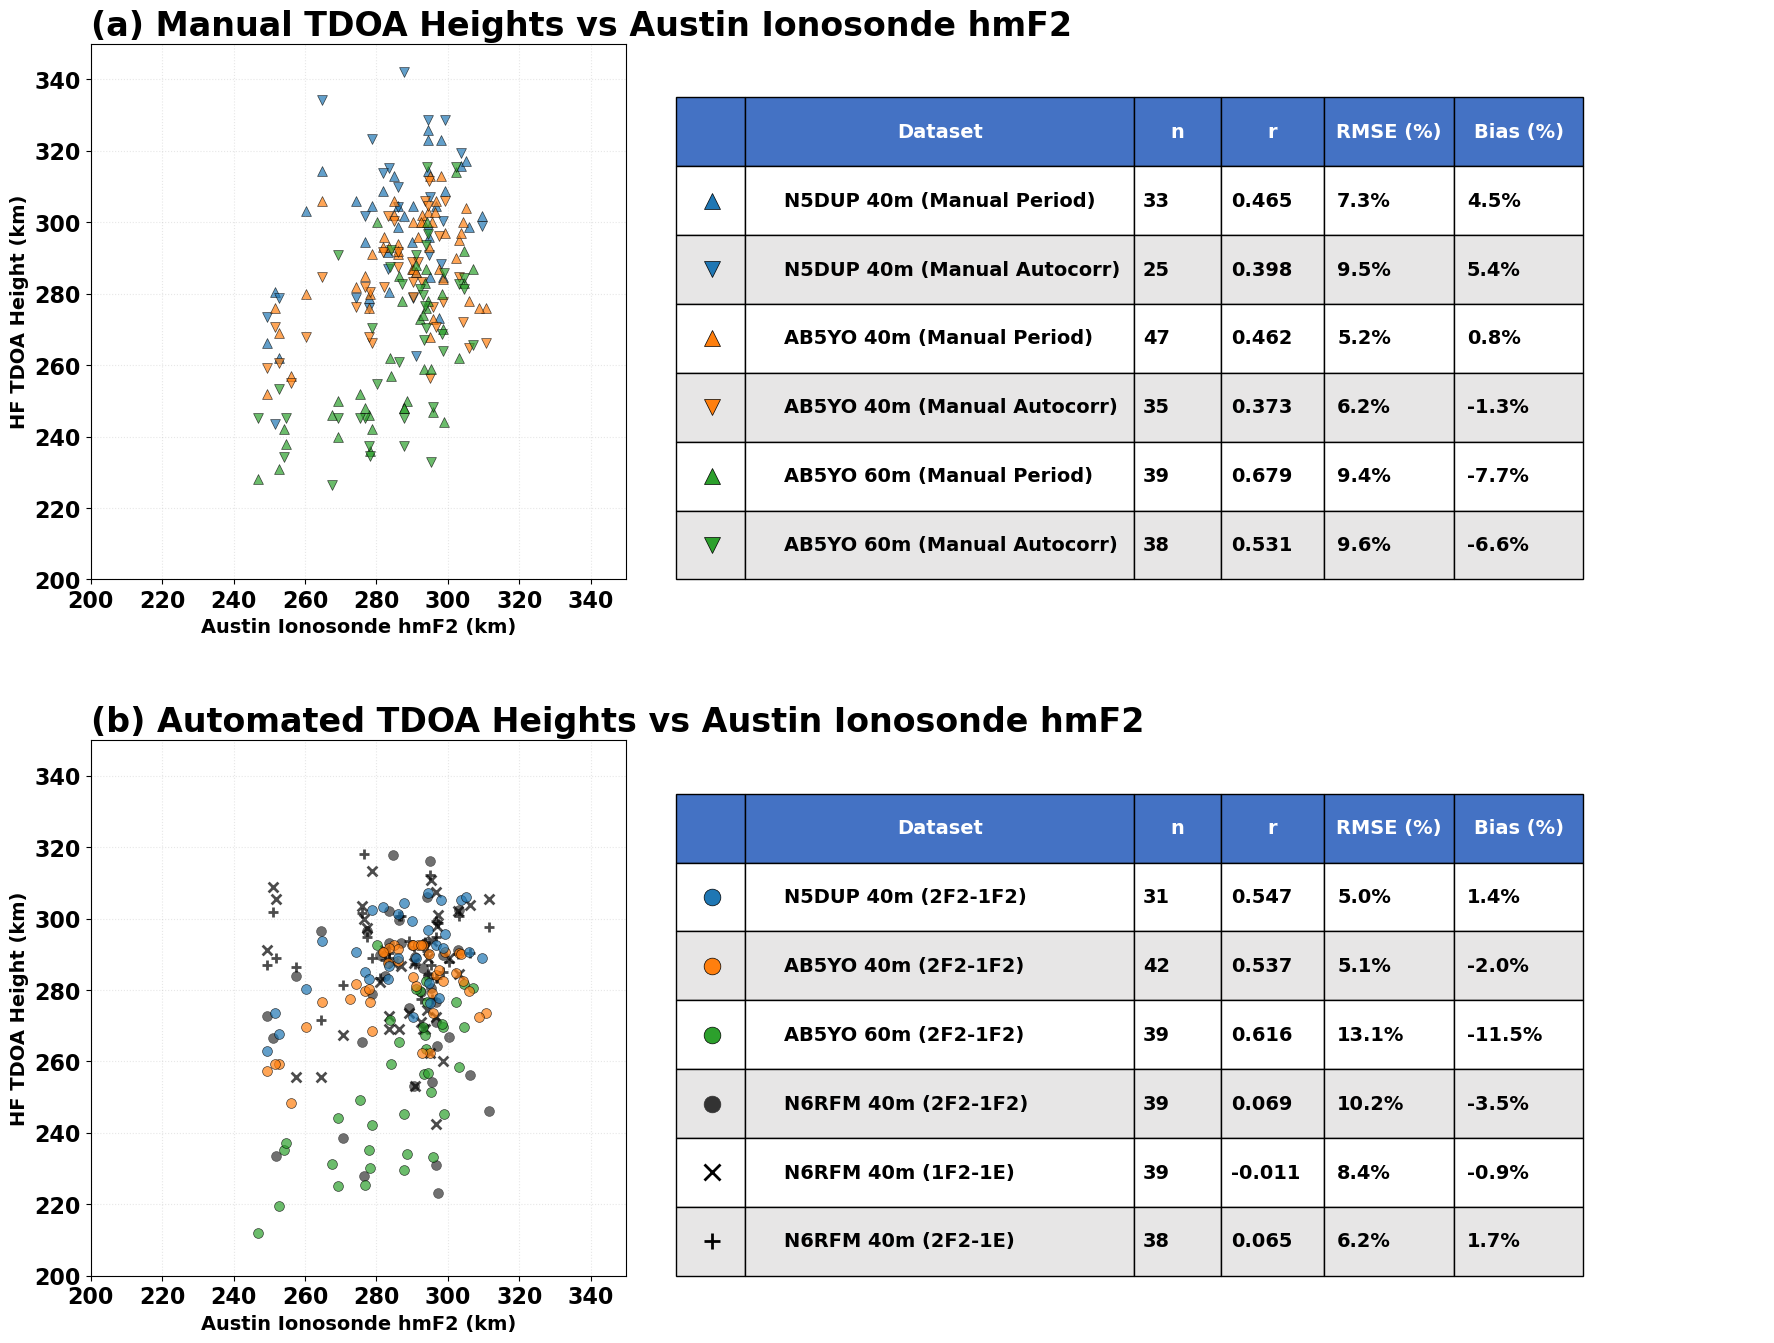

In [7]:
# Create combined scatter plot comparing manual vs automated analysis
print("Creating 2x2 scatter plot figure (manual vs automated)...\n")

results_combined = tdoa.create_manual_vs_automated_scatter_figure(
    manual_datasets,
    automated_datasets,
    ionosonde_df,
    filepath='fig_14.jpg'
)

print("\nFigure 14 saved to: fig_14.jpg")

# Print summary statistics for manual analysis
print("\n" + "="*80)
print("MANUAL ANALYSIS STATISTICS")
print("="*80)
print(f"{'Dataset':<35s} {'n':>6s} {'r':>8s} {'RMSE (%)':>12s} {'Bias (%)':>12s}")
print("-"*80)

for label, stats in results_combined['manual'].items():
    if stats:
        print(f"{label:<35s} {stats['n_points']:6d} {stats['correlation']:8.3f} "
              f"{stats['rmse_percent']:11.1f}% {stats['bias_percent']:11.1f}%")

# Print summary statistics for automated analysis
print("\n" + "="*80)
print("AUTOMATED ANALYSIS STATISTICS")
print("="*80)
print(f"{'Dataset':<35s} {'n':>6s} {'r':>8s} {'RMSE (%)':>12s} {'Bias (%)':>12s}")
print("-"*80)

for label, stats in results_combined['automated'].items():
    if stats:
        print(f"{label:<35s} {stats['n_points']:6d} {stats['correlation']:8.3f} "
              f"{stats['rmse_percent']:11.1f}% {stats['bias_percent']:11.1f}%")

print("="*80)

## Summary

This notebook has created comprehensive scatter plot comparisons between HF TDOA height measurements and Austin Ionosonde hmF2 values, comparing both manual and automated analysis methods.

### Outputs Generated:

1. **Resampling Validation Plots** (`output/resample_validation_*.jpg`)
   - Shows original vs resampled data for each dataset
   - Separate plots for manual and automated analysis
   - Verifies that 5-minute resampling preserves data fidelity

2. **Individual Scatter Plots** (`output/scatter_*.jpg`)
   - One plot per dataset vs ionosonde
   - Separate plots for manual and automated datasets
   - Includes correlation statistics (r, RMSE, bias, percent error)

3. **Combined 2x2 Scatter Plot** (`output/scatter_manual_vs_automated.jpg`)
   - Top row (a-b): Manual analysis scatter plot and statistics table
   - Bottom row (c-d): Automated analysis scatter plot and statistics table
   - Color-coded by dataset with unique markers
   - Integrated statistics tables with symbols
   - Provides comprehensive comparison view

### Key Findings:

The statistics tables show the correlation (r), root mean square error (RMSE %), and bias (%) for each dataset compared to the ionosonde hmF2 measurements. These metrics allow quantitative assessment of:

**Manual Analysis Methods:**
- Period analysis: Manual measurement of chirp repetition period
- Autocorrelation analysis: Automated detection using autocorrelation

**Automated Analysis Methods:**
- Multiple propagation modes: 2F2-1F2, 1F2-1E, 2F2-1E
- Multiple receiver locations: N5DUP, AB5YO, N6RFM
- Multiple frequency bands: 40m and 60m

**Comparison Metrics:**
- **n**: Number of matched data points with ionosonde measurements
- **r**: Correlation coefficient (closer to 1.0 indicates better linear agreement)
- **RMSE (%)**: Root mean square error as percent of mean ionosonde height
- **Bias (%)**: Systematic offset as percent of mean ionosonde height

The comparison enables evaluation of:
- Agreement between manual and automated TDOA methods
- Performance of different propagation modes
- Consistency across different receiver locations and frequency bands
- Overall accuracy of TDOA-based ionospheric height estimation